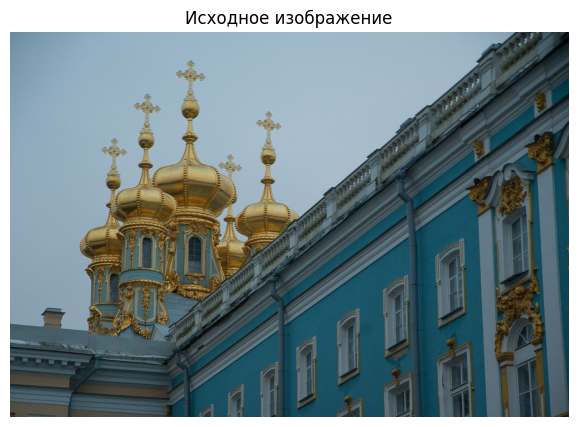

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

%matplotlib inline

image = cv2.imread("image.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 5))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Исходное изображение")
plt.show()

In [2]:
height, width, _ = image_rgb.shape

print("Ширина изображения в пикселях:", width)
print("Высота изображения в пикселях:", height)
print("Среднее значение интенсивности пикселя изображения:", round(float(image_rgb.mean()), 3))

Высота изображения в пикселях: 883
Ширина изображения в пикселях: 1280
Среднее значение интенсивности пикселя изображения: 108.763


In [3]:
def exposure(img, p):
    transformed = img.astype(np.float64) * (2 ** p)
    transformed = np.clip(transformed, 0, 255)
    return np.rint(transformed).astype(np.uint8)

for p in (-0.31, 0.39):
    transformed = exposure(image_rgb, p)
    print(
        f"Среднее значение интенсивности пикселя преобразованного изображения при p = {p}:",
        round(float(np.mean(transformed)), 3),
    )

Среднее значение интенсивности пикселя преобразованного изображения при p = -0.31: 87.731
Среднее значение интенсивности пикселя преобразованного изображения при p = 0.39: 141.992


In [4]:
def contrast(img, p):
    transformed = img.astype(np.float64) / 255.0

    if p > 0:
        transformed = (transformed - 0.5) / (1.0 - p)
    else:
        transformed = (transformed - 0.5) * (1.0 - p)

    transformed = np.clip(transformed, 0, 1)
    transformed = np.rint(transformed * 255.0)
    return transformed.astype(np.uint8)

for p in (-0.31, 0.39):
    transformed = contrast(image_rgb, p)
    print(
        f"Среднее значение интенсивности пикселя преобразованного изображения при p = {p}:",
        round(float(np.mean(transformed)), 3),
    )

Среднее значение интенсивности пикселя преобразованного изображения при p = -0.31: 22.515
Среднее значение интенсивности пикселя преобразованного изображения при p = 0.39: 28.164
